In [ ]:
import kagglehub
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

path = Path(kagglehub.dataset_download("samlearner/letterboxd-movie-ratings-data"))

movie_data = pd.read_csv(path / "movie_data.csv", on_bad_lines="skip", engine="python")
ratings_data = pd.read_csv(
    path / "ratings_export.csv", on_bad_lines="skip", engine="python"
)
users_data = pd.read_csv(
    path / "users_export.csv", on_bad_lines="skip", engine="python"
)

display(movie_data.head())

,_id,genres,image_url,imdb_id,imdb_link,movie_id,movie_title,original_language,overview,popularity,production_countries,release_date,runtime,spoken_languages,tmdb_id,tmdb_link,vote_average,vote_count,year_released
0,5fc85f606758f69634496fd3,"[""Music"",""Animation""]",film-poster/4/6/4/4/4/0/464440-football-freaks...,NaN,NaN,football-freaks,Football Freaks,en,"Football crazy, football mad. Don’t watch this...",0.600,"[""United Kingdom""]",1971-12-05,0.0,[],535272.0,https://www.themoviedb.org/movie/535272/,0.0,0.0,1971.0
1,5fc85ff26758f696344ace0c,[],film-poster/2/4/5/5/0/0/245500-aftermath-0-230...,tt0586129,http://www.imdb.com/title/tt0586129/maindetails,aftermath-1960,Aftermath,en,Aftermath was the pilot for an unsold TV serie...,0.600,[],1960-04-17,22.0,[],318331.0,https://www.themoviedb.org/movie/318331/,8.0,1.0,1960.0
2,5fc85f606758f69634496fcd,"[""Drama""]",film-poster/9/3/3/1/8/93318-where-chimneys-are...,tt0045731,http://www.imdb.com/title/tt0045731/maindetails,where-chimneys-are-seen,Where Chimneys Are Seen,ja,Gosho’s most celebrated film both in Japan and...,1.568,"[""Japan""]",1953-03-05,108.0,"[""日本語""]",117779.0,https://www.themoviedb.org/movie/117779/,6.6,10.0,1953.0
3,5fc85f606758f69634496fd1,"[""Drama""]",NaN,tt0187327,http://www.imdb.com/title/tt0187327/maindetails,the-musicians-daughter,The Musician's Daughter,en,Carl Wagner's good wife was dying. His heart b...,0.600,"[""United States of America""]",1911-12-12,15.0,[],560377.0,https://www.themoviedb.org/movie/560377/,0.0,0.0,1911.0
4,5fc85f606758f69634496fd4,"[""Documentary""]",film-poster/4/5/4/6/0/3/454603-50-years-of-fab...,tt4769914,http://www.imdb.com/title/tt4769914/maindetails,50-years-of-fabulous,50 Years of Fabulous,en,50 Years of Fabulous recounts the rich history...,0.600,[],2018-05-17,75.0,[],525187.0,https://www.themoviedb.org/movie/525187/,0.0,0.0,2018.0


In [14]:
movie_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 285963 entries, 0 to 285962
Data columns (total 19 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   _id                   285963 non-null  str    
 1   genres                274986 non-null  str    
 2   image_url             264521 non-null  str    
 3   imdb_id               243898 non-null  str    
 4   imdb_link             243914 non-null  str    
 5   movie_id              285616 non-null  str    
 6   movie_title           283453 non-null  str    
 7   original_language     274986 non-null  str    
 8   overview              261362 non-null  str    
 9   popularity            274872 non-null  float64
 10  production_countries  274854 non-null  str    
 11  release_date          270954 non-null  str    
 12  runtime               269943 non-null  float64
 13  spoken_languages      274758 non-null  str    
 14  tmdb_id               279803 non-null  float64
 15  tmdb_link  

In [12]:
ratings_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 11078167 entries, 0 to 11078166
Data columns (total 4 columns):
 #   Column      Dtype
---  ------      -----
 0   _id         str  
 1   movie_id    str  
 2   rating_val  int64
 3   user_id     str  
dtypes: int64(1), str(3)
memory usage: 338.1 MB


In [13]:
users_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 8139 entries, 0 to 8138
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   _id                8139 non-null   str    
 1   display_name       7832 non-null   str    
 2   num_ratings_pages  4747 non-null   float64
 3   num_reviews        8139 non-null   int64  
 4   username           8139 non-null   str    
dtypes: float64(1), int64(1), str(3)
memory usage: 318.1 KB


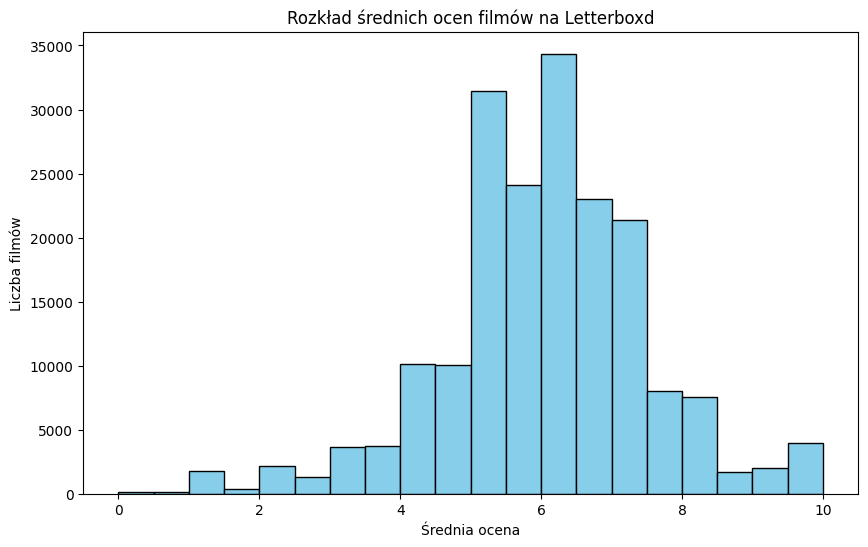

In [ ]:
# Rozkład średnich ocen filmów (wykluczając filmy bez oceny)
# Odrzucenie filmów bez oceny i tych, na które nikt nie zagłosował
df_rozklad = movie_data.dropna(subset=["vote_average", "vote_count"])
df_rozklad = df_rozklad[df_rozklad["vote_count"] > 0]

plt.figure(figsize=(10, 6))

plt.hist(df_rozklad["vote_average"], bins=20, color="skyblue", edgecolor="black")

plt.title("Rozkład średnich ocen filmów na Letterboxd")
plt.xlabel("Średnia ocena")
plt.ylabel("Liczba filmów")

plt.show()

In [ ]:
# Wykluczenie pustych wartości
df_kraje = movie_data[movie_data["production_countries"] != "[]"]

# Konwersja danych na listę krajów po przecinku (dzięki temu, 
# gdy do jednego filmu przyporządkowanych jest kilka krajów, każdy z nich "otrzymuje 1 punkt")
df_kraje["czyste_kraje"] = df_kraje["production_countries"].str.replace(
    r"[\[\]\'\"]", "", regex=True
)
df_kraje["czyste_kraje"] = df_kraje["czyste_kraje"].str.split(",")
df_eksplozja = df_kraje.explode("czyste_kraje")

# Wyświetlenie 15 najwyższych wyników
top_kraje = df_eksplozja["czyste_kraje"].value_counts().head(15).reset_index()
top_kraje.columns = ["Kraj produkcji", "Liczba filmów"]

print("Top 15 krajów z największą liczbą filmów w bazie Letterboxd:")
display(top_kraje)

Top 15 krajów z największą liczbą filmów w bazie Letterboxd:


,Kraj produkcji,Liczba filmów
0,United States of America,73368
1,United Kingdom,17783
2,France,16271
3,Germany,11499
4,Japan,10936
5,Canada,8611
6,Italy,7721
7,India,6427
8,Mexico,6098
9,Spain,5833


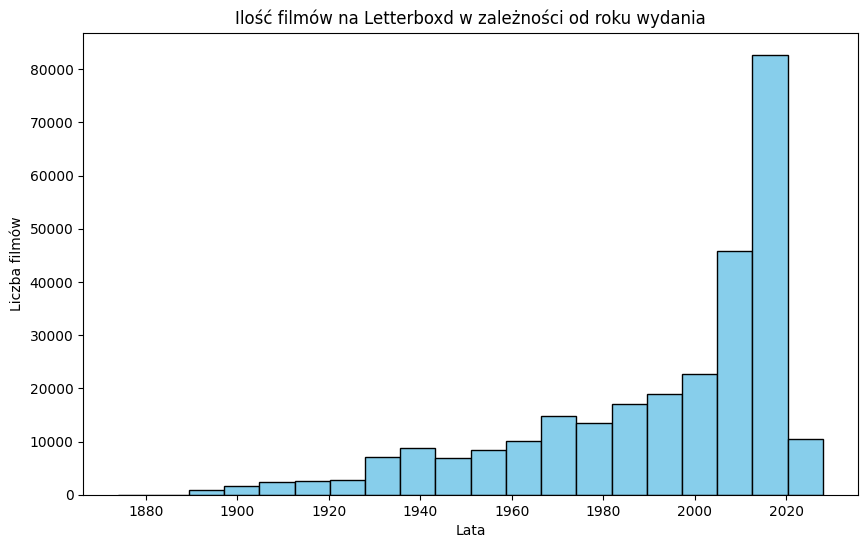

In [35]:
# Ilość filmów na Letterboxd w zależności od roku wydania
df_rozklad = movie_data.dropna(subset=["year_released"])

plt.figure(figsize=(10, 6))

plt.hist(df_rozklad["year_released"], bins=20, color="skyblue", edgecolor="black")

plt.title("Ilość filmów na Letterboxd w zależności od roku wydania")
plt.xlabel("Lata")
plt.ylabel("Liczba filmów")

plt.show()

In [ ]:
# Najczęstsze gatunki filmowe
# Wykluczenie pustych danych
df_gatunki = movie_data.dropna(subset=["genres"]).copy()
df_gatunki = df_gatunki[df_gatunki["genres"] != "[]"]

df_gatunki["czyste_gatunki"] = df_gatunki["genres"].str.replace(
    r"[\[\]\'\"]", "", regex=True
)
df_gatunki["czyste_gatunki"] = df_gatunki["czyste_gatunki"].str.split(",")
df_eksplozja = df_gatunki.explode("czyste_gatunki")

# Wyświetlenie 15 najwyższych wyników
top_gatunki = df_eksplozja["czyste_gatunki"].value_counts().head(15).reset_index()
top_gatunki.columns = ["Gatunek", "Liczba filmów"]

print("Najczęstsze gatunki:")
display(top_gatunki)

Najpopularniejsze gatunki:


,Gatunek,Liczba filmów
0,Drama,82903
1,Comedy,55540
2,Documentary,39575
3,Thriller,22225
4,Horror,21812
5,Romance,21783
6,Action,20464
7,Animation,19789
8,Crime,15114
9,Music,12657


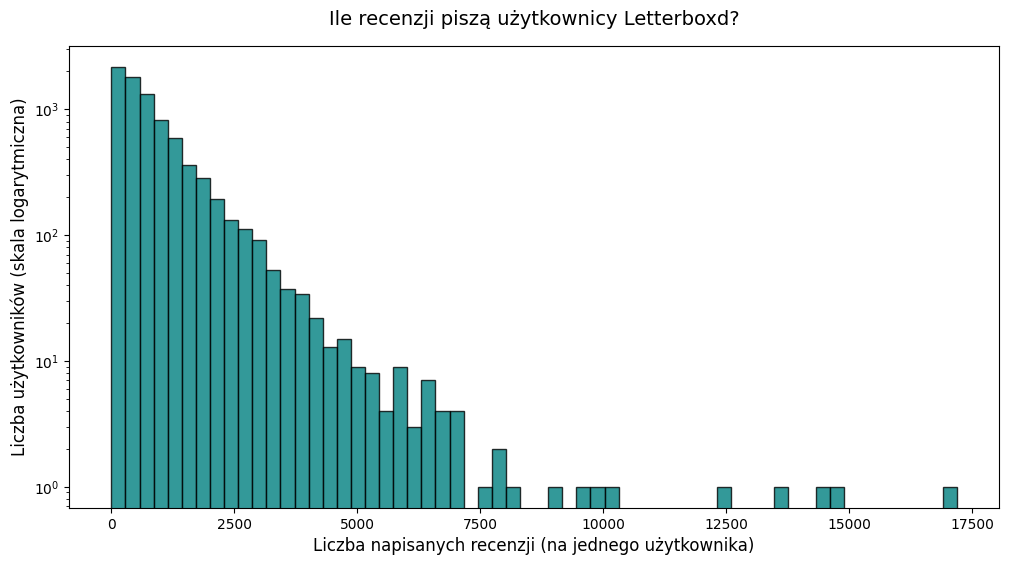

Podsumowanie:
Średnia liczba recenzji na osobę: 868.4
Mediana: 588
Rekordzista napisał: 17184 recenzji.
Liczba osób, które nie napisały ani jednej recenzji: 78
Top 10 recenzentów:


,username,display_name,num_reviews
3546,michael_elliott,Michael_Elliott,17184
2943,punq,PUNQ,14642
2064,tubbs,STEPHEN TUBBS,14477
3049,matt_thomas10,Matt Thomas,13521
1293,greg_wood,Gregory Wood,12377
3204,hotsake,hotsake,10080
1762,chrissweet1967,Chris Sweet,9842
3311,stevenmillan,Steven Millan,9547
3536,aaronblocke,Aaron King,9107
3154,lencho_o_t_apes,Lencho of the Apes,8195


In [63]:
# Ile recenzji piszą użytkownicy Letterboxd?
recenzje = users_data["num_reviews"]

plt.figure(figsize=(12, 6))

plt.hist(recenzje, bins=60, color="teal", edgecolor="black", log=True, alpha=0.8)

plt.title("Ile recenzji piszą użytkownicy Letterboxd?", fontsize=14, pad=15)
plt.xlabel("Liczba napisanych recenzji (na jednego użytkownika)", fontsize=12)
plt.ylabel("Liczba użytkowników (skala logarytmiczna)", fontsize=12)

plt.show()

print("Podsumowanie:")
print(f"Średnia liczba recenzji na osobę: {recenzje.mean():.1f}")
print(f"Mediana: {recenzje.median():.0f}")
print(f"Rekordzista napisał: {recenzje.max()} recenzji.")
print(f"Liczba osób, które nie napisały ani jednej recenzji: {(recenzje == 0).sum()}")

top_recenzenci = users_data.sort_values(by="num_reviews", ascending=False).head(10)
print("Top 10 recenzentów:")
display(top_recenzenci[["username", "display_name", "num_reviews"]])